In [242]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression, Ridge
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler

In [243]:
df=pd.read_excel(r'C:\Users\91798\OneDrive\Desktop\Health-Insurance-Prediction\data\premiums_with_life_style.xlsx')
df.head()

,Age,Gender,Region,Marital_status,Physical_Activity,Stress_Level,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,Silver,21108
2,18,Female,Southwest,Unmarried,Medium,High,0,Normal,No Smoking,Freelancer,<10L,9,No Disease,Bronze,8459
3,55,Male,Northeast,Married,High,Medium,3,Overweight,Occasional,Salaried,<10L,9,Thyroid,Silver,21685
4,22,Male,Southeast,Unmarried,Medium,High,2,Normal,Regular,Self-Employed,10L - 25L,13,High blood pressure & Heart disease,Bronze,15984


In [244]:
df.columns=df.columns.str.replace(' ','_').str.lower()
df.head(5)

,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,Silver,21108
2,18,Female,Southwest,Unmarried,Medium,High,0,Normal,No Smoking,Freelancer,<10L,9,No Disease,Bronze,8459
3,55,Male,Northeast,Married,High,Medium,3,Overweight,Occasional,Salaried,<10L,9,Thyroid,Silver,21685
4,22,Male,Southeast,Unmarried,Medium,High,2,Normal,Regular,Self-Employed,10L - 25L,13,High blood pressure & Heart disease,Bronze,15984


In [245]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,41.316300,3.192900,23.339900,19505.063900
std,57.971661,21.650454,32.302974,8893.649171
min,18.000000,0.000000,1.000000,3582.000000
25%,24.000000,0.000000,6.000000,11777.750000
50%,37.000000,2.000000,16.000000,19312.000000
75%,50.000000,3.000000,31.000000,26494.500000
max,1178.000000,456.000000,960.000000,45854.000000


In [246]:
df.isna().sum()

age                       0
gender                    0
region                    0
marital_status            0
physical_activity         0
stress_level              0
number_of_dependants      0
bmi_category              0
smoking_status            9
employment_status         7
income_level             18
income_lakhs              0
medical_history           0
insurance_plan            0
annual_premium_amount     0
dtype: int64

In [247]:
df.dropna(inplace=True)

In [248]:
df.drop_duplicates(inplace=True)

In [249]:
df.number_of_dependants.unique()

array([  2,   5,   0,   3,   1,   4, 456,  78, 230])

In [250]:
len(df[(df['age']>100) | (df['age']<0)])

58

In [251]:
numeric_features=df.select_dtypes(include=['int64','float64']).columns
numeric_features

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='str')

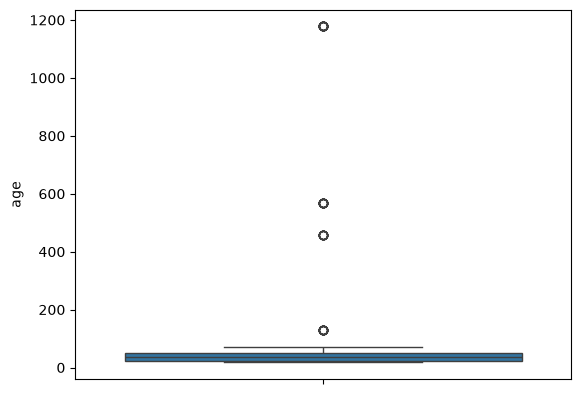

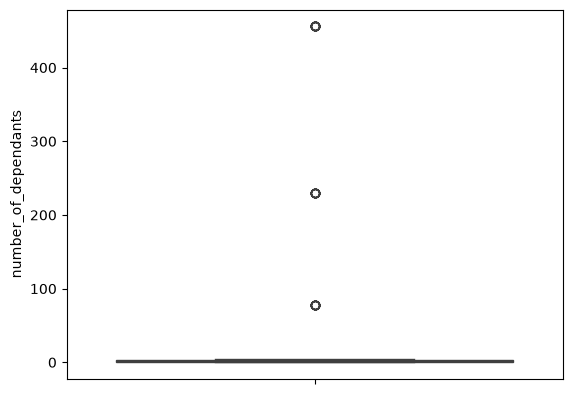

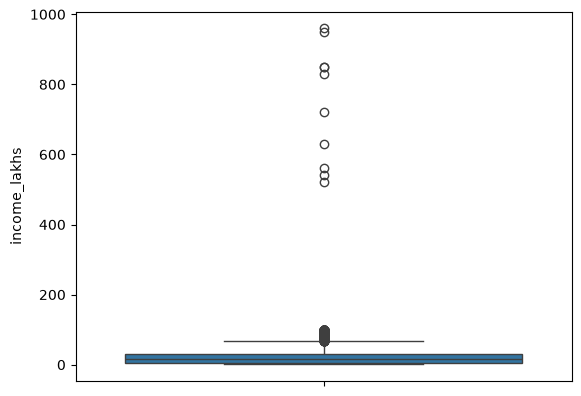

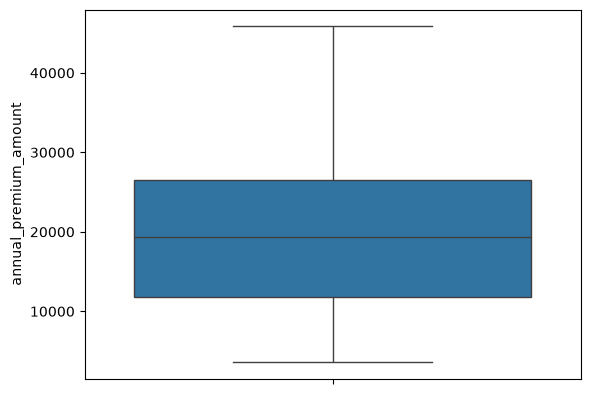

In [252]:
for col in numeric_features:
    sns.boxplot(df[col])
    plt.show()

In [253]:
def calculate_outlier_limits(data):
    Q1=data.quantile(0.25)
    Q3=data.quantile(0.75)
    IQR=Q3-Q1
    lower_limit=Q1-1.5*IQR
    upper_limit=Q3+1.5*IQR

    return lower_limit,upper_limit

In [254]:
lower_limit,upper_limit=calculate_outlier_limits(df['age'].copy())
df1=df[(df['age']>lower_limit) & (df['age']<upper_limit)].copy()

In [255]:
df1.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,9915.000000,9915.000000,9915.000000,9915.000000
mean,37.743621,3.203429,23.400807,19496.715784
std,13.975462,21.742340,32.398236,8899.088302
min,18.000000,0.000000,1.000000,3582.000000
25%,24.000000,0.000000,6.000000,11765.500000
50%,37.000000,2.000000,16.000000,19309.000000
75%,50.000000,3.000000,31.000000,26493.000000
max,72.000000,456.000000,960.000000,45854.000000


In [256]:
lower_limit,upper_limit=calculate_outlier_limits(df1['number_of_dependants'].copy())
df2=df1[(df1['number_of_dependants']>lower_limit) & (df1['number_of_dependants']<upper_limit)].copy()

In [257]:
df2.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,9868.000000,9868.000000,9868.000000,9868.000000
mean,37.756486,1.919133,23.411634,19511.417714
std,13.976822,1.503264,32.437621,8900.941540
min,18.000000,0.000000,1.000000,3582.000000
25%,24.000000,0.000000,6.000000,11776.250000
50%,37.000000,2.000000,16.000000,19327.500000
75%,50.000000,3.000000,31.000000,26505.250000
max,72.000000,5.000000,960.000000,45854.000000


In [258]:
df3=df2[df2['income_lakhs']<df2['income_lakhs'].quantile(0.99)]

In [259]:
df3.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,9767.000000,9767.000000,9767.000000,9767.000000
mean,37.758063,1.919832,21.976656,19479.674721
std,13.972228,1.502548,21.323039,8896.446809
min,18.000000,0.000000,1.000000,3582.000000
25%,24.000000,0.000000,6.000000,11754.500000
50%,37.000000,2.000000,16.000000,19300.000000
75%,50.000000,3.000000,31.000000,26466.500000
max,72.000000,5.000000,96.000000,45854.000000


In [260]:
df3.head(5)

,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,Silver,21108
2,18,Female,Southwest,Unmarried,Medium,High,0,Normal,No Smoking,Freelancer,<10L,9,No Disease,Bronze,8459
3,55,Male,Northeast,Married,High,Medium,3,Overweight,Occasional,Salaried,<10L,9,Thyroid,Silver,21685
4,22,Male,Southeast,Unmarried,Medium,High,2,Normal,Regular,Self-Employed,10L - 25L,13,High blood pressure & Heart disease,Bronze,15984


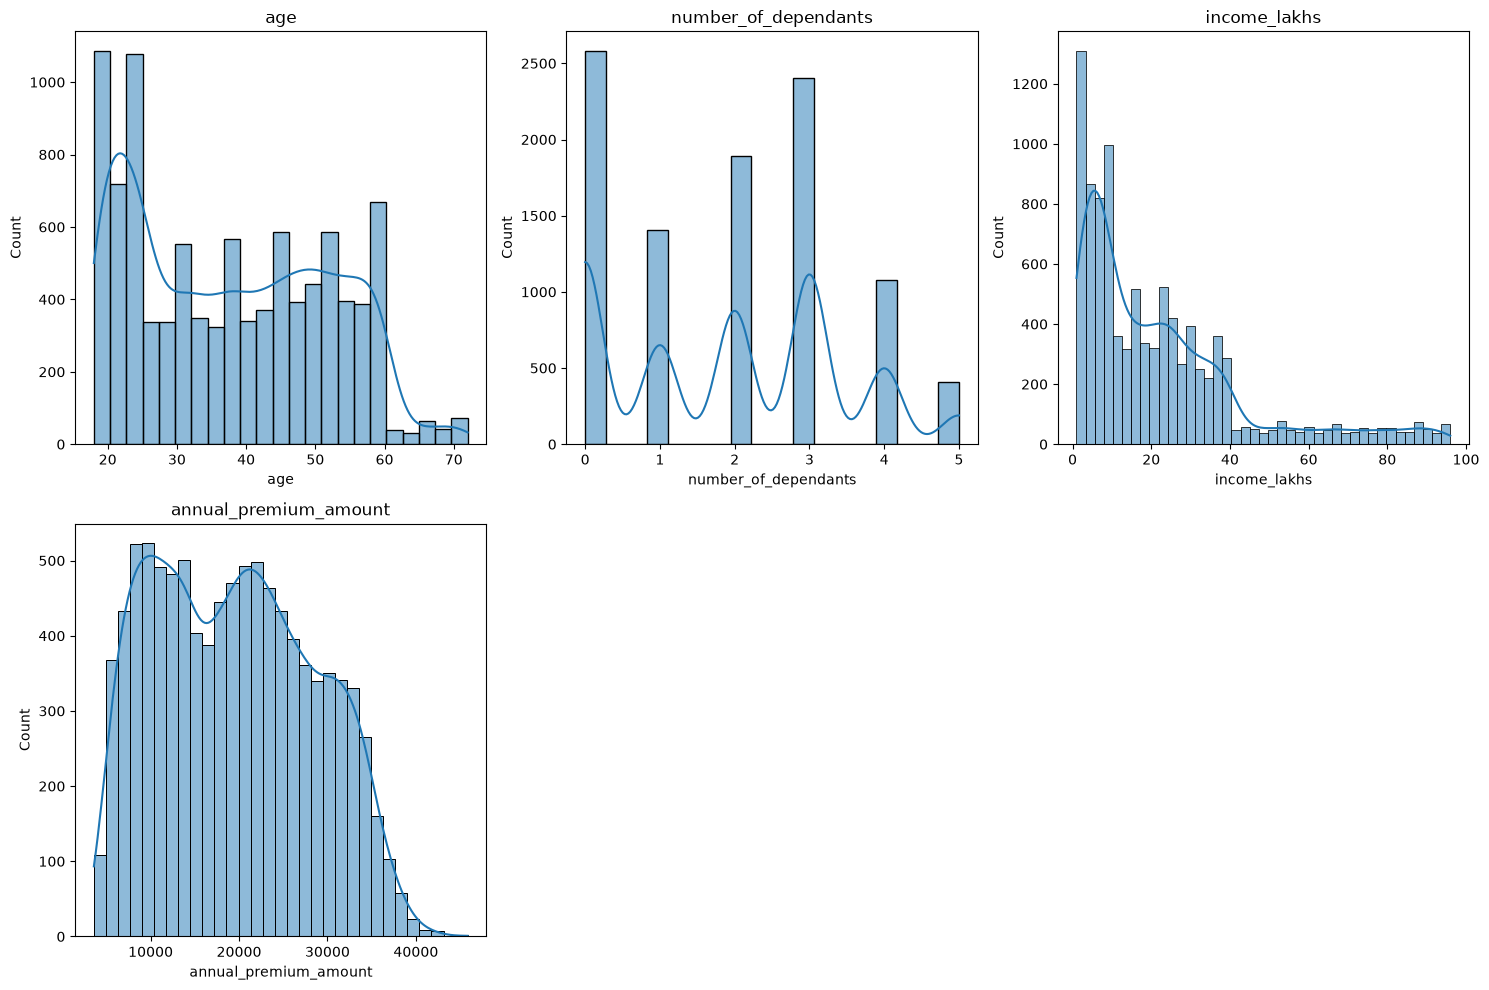

In [261]:
#numeric_features
fig,axs=plt.subplots(2,3,figsize=(15,10))
for i,col in enumerate(numeric_features):
    ax=axs[i//3,i%3]
    sns.histplot(df3[col],kde=True,ax=ax)
    ax.set_title(col)


if len(numeric_features)%3!=0:
    for j in range(len(numeric_features),6):
        axs.flat[j].set_visible(False)

plt.tight_layout()
plt.show()

In [262]:
cat_features=df3.select_dtypes('str').columns
cat_features

Index(['gender', 'region', 'marital_status', 'physical_activity',
       'stress_level', 'bmi_category', 'smoking_status', 'employment_status',
       'income_level', 'medical_history', 'insurance_plan'],
      dtype='str')

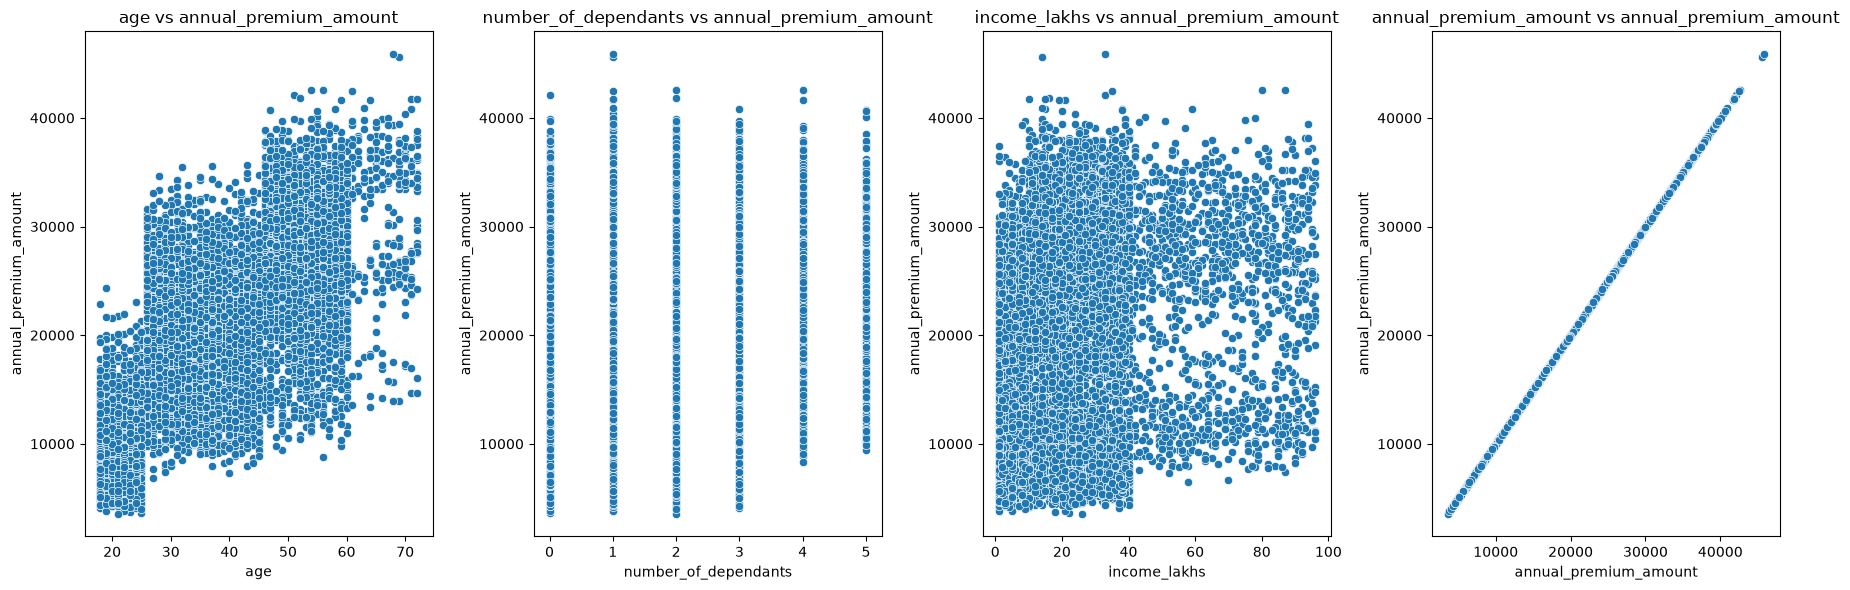

In [263]:
fig,axs=plt.subplots(1,len(numeric_features),figsize=(18,6))

for ax,col in zip(axs,numeric_features):
    sns.scatterplot(x=df3[col],y=df3['annual_premium_amount'],ax=ax)
    ax.set_title(f'{col} vs annual_premium_amount')
    ax.set_xlabel(col)
    ax.set_ylabel('annual_premium_amount')
plt.tight_layout()
plt.show()

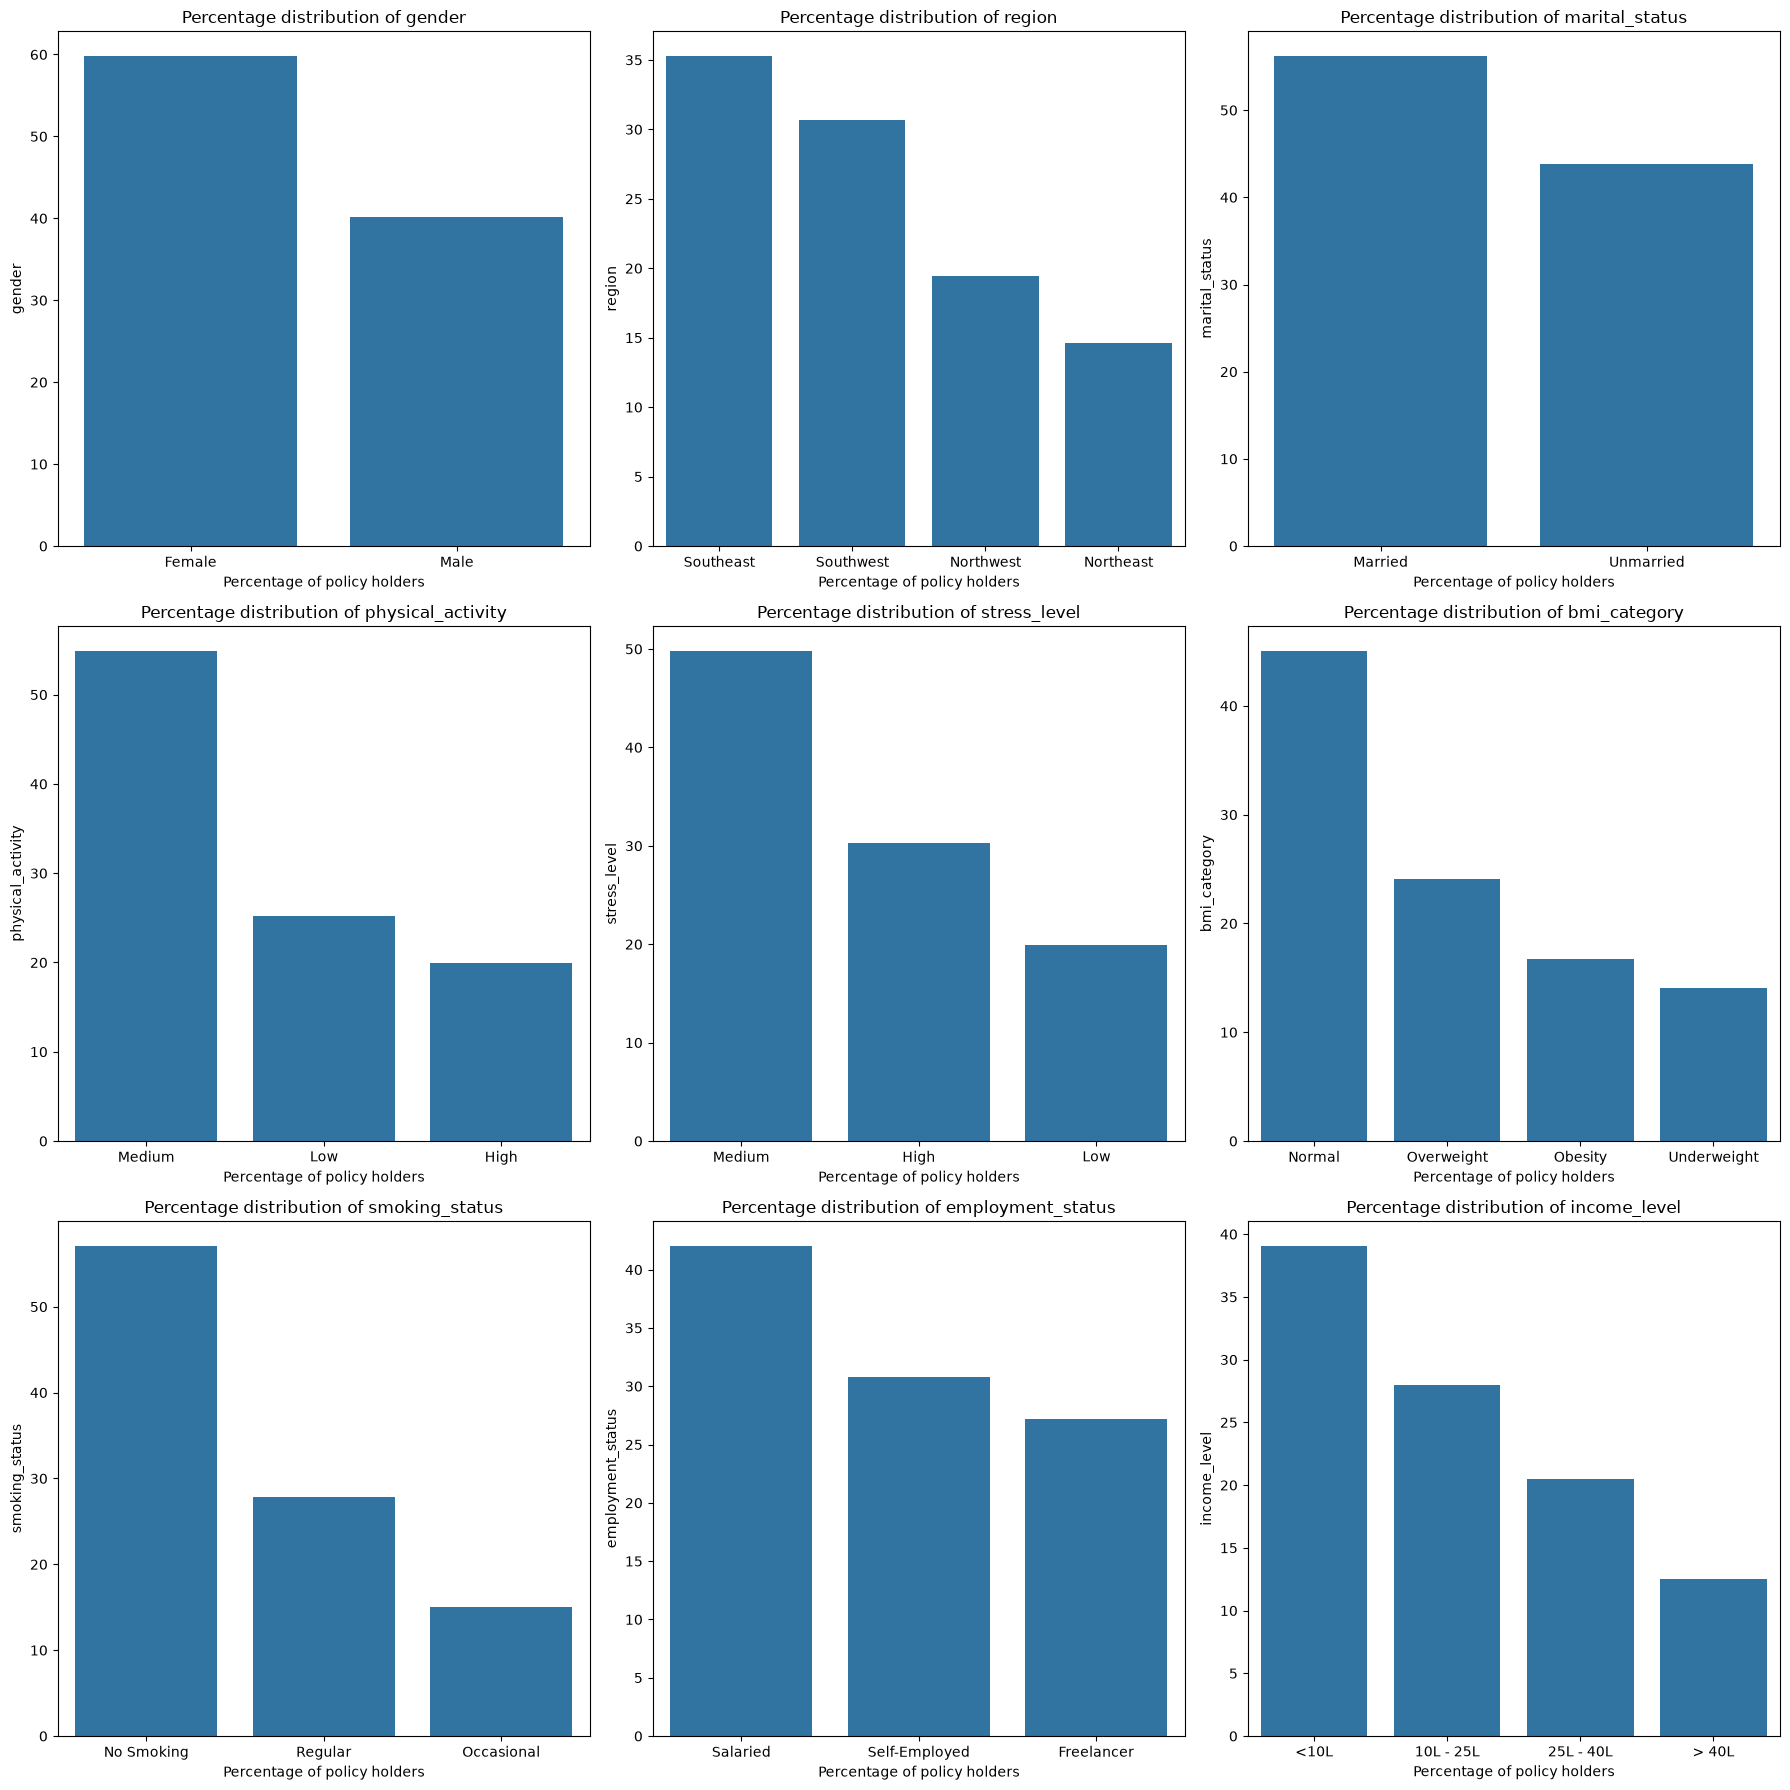

In [264]:
fig,axs=plt.subplots(nrows=3,ncols=3,figsize=(18,18))
axs=axs.flatten()

for ax,col in zip(axs,cat_features):
    cat_values=df3[col].value_counts(normalize=True)*100
    sns.barplot(x=cat_values.index,y=cat_values.values,ax=ax)
    ax.set_title(f'Percentage distribution of {col}')
    ax.set_xlabel('Percentage of policy holders')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

In [265]:
df3[['disease1','disease2']]=df3['medical_history'].str.split(' & ',expand=True)

In [266]:
df3['disease1'] = df3['disease1'].fillna('None')
df3['disease2'] = df3['disease2'].fillna('None')

In [267]:
risk_scores = {
    "Diabetes": 6,
    "Heart disease": 8,
    "High blood pressure": 6,
    "Thyroid": 5,
    "No Disease": 0,
    "None": 0
}

In [268]:
df3['total_risk'] = df3['disease1'].map(risk_scores)+df3['disease2'].map(risk_scores)
df3.head()

,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944,High blood pressure,None,6
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,Silver,21108,No Disease,None,0
2,18,Female,Southwest,Unmarried,Medium,High,0,Normal,No Smoking,Freelancer,<10L,9,No Disease,Bronze,8459,No Disease,None,0
3,55,Male,Northeast,Married,High,Medium,3,Overweight,Occasional,Salaried,<10L,9,Thyroid,Silver,21685,Thyroid,None,5
4,22,Male,Southeast,Unmarried,Medium,High,2,Normal,Regular,Self-Employed,10L - 25L,13,High blood pressure & Heart disease,Bronze,15984,High blood pressure,Heart disease,14


In [269]:
df3.drop(columns=['medical_history','disease1','disease2'],inplace=True)

In [270]:
df3.head()

,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,total_risk
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,Gold,27944,6
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,Silver,21108,0
2,18,Female,Southwest,Unmarried,Medium,High,0,Normal,No Smoking,Freelancer,<10L,9,Bronze,8459,0
3,55,Male,Northeast,Married,High,Medium,3,Overweight,Occasional,Salaried,<10L,9,Silver,21685,5
4,22,Male,Southeast,Unmarried,Medium,High,2,Normal,Regular,Self-Employed,10L - 25L,13,Bronze,15984,14


In [271]:
df3['physical_activity'] = df3['physical_activity'].map({'Low':4,'Medium':1,'High':0})
df3['stress_level'] = df3['stress_level'].map({'Low':0,'Medium':1,'High':4})
df3['insurance_plan']  = df3['insurance_plan'].map({'Gold':3,'Silver':2,'Bronze':1})
df3['income_level'] = df3['income_level'].map({'25L - 40L':3,'10L - 25L':2,'<10L':1,'> 40L':4})

In [272]:
df3.head(5)

,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,total_risk
0,56,Female,Southeast,Unmarried,1,1,2,Normal,No Smoking,Self-Employed,3,37,3,27944,6
1,38,Female,Northeast,Married,4,4,5,Overweight,Occasional,Freelancer,2,10,2,21108,0
2,18,Female,Southwest,Unmarried,1,4,0,Normal,No Smoking,Freelancer,1,9,1,8459,0
3,55,Male,Northeast,Married,0,1,3,Overweight,Occasional,Salaried,1,9,2,21685,5
4,22,Male,Southeast,Unmarried,1,4,2,Normal,Regular,Self-Employed,2,13,1,15984,14


In [273]:
df3['life_style_risk'] = df3['physical_activity']+df3['stress_level']

In [274]:
df3.head()

,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,total_risk,life_style_risk
0,56,Female,Southeast,Unmarried,1,1,2,Normal,No Smoking,Self-Employed,3,37,3,27944,6,2
1,38,Female,Northeast,Married,4,4,5,Overweight,Occasional,Freelancer,2,10,2,21108,0,8
2,18,Female,Southwest,Unmarried,1,4,0,Normal,No Smoking,Freelancer,1,9,1,8459,0,5
3,55,Male,Northeast,Married,0,1,3,Overweight,Occasional,Salaried,1,9,2,21685,5,1
4,22,Male,Southeast,Unmarried,1,4,2,Normal,Regular,Self-Employed,2,13,1,15984,14,5


In [275]:
df3.drop(columns=['physical_activity','stress_level'],inplace=True)

In [276]:
df3.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,total_risk,life_style_risk
0,56,Female,Southeast,Unmarried,2,Normal,No Smoking,Self-Employed,3,37,3,27944,6,2
1,38,Female,Northeast,Married,5,Overweight,Occasional,Freelancer,2,10,2,21108,0,8
2,18,Female,Southwest,Unmarried,0,Normal,No Smoking,Freelancer,1,9,1,8459,0,5
3,55,Male,Northeast,Married,3,Overweight,Occasional,Salaried,1,9,2,21685,5,1
4,22,Male,Southeast,Unmarried,2,Normal,Regular,Self-Employed,2,13,1,15984,14,5


In [277]:
nominal_features=['gender','region','marital_status','smoking_status','employment_status']
df3[nominal_features]

,gender,region,marital_status,smoking_status,employment_status
0,Female,Southeast,Unmarried,No Smoking,Self-Employed
1,Female,Northeast,Married,Occasional,Freelancer
2,Female,Southwest,Unmarried,No Smoking,Freelancer
3,Male,Northeast,Married,Occasional,Salaried
4,Male,Southeast,Unmarried,Regular,Self-Employed
...,...,...,...,...,...
9995,Male,Northeast,Married,Regular,Freelancer
9996,Male,Southwest,Unmarried,No Smoking,Freelancer
9997,Male,Southeast,Unmarried,Regular,Freelancer
9998,Female,Northwest,Unmarried,Occasional,Self-Employed


In [278]:
df3=pd.get_dummies(df3,columns=nominal_features,drop_first=True,dtype=int)
df3['bmi_category'].unique()

<StringArray>
['Normal', 'Overweight', 'Obesity', 'Underweight']
Length: 4, dtype: str

In [279]:
df3['bmi_category']=df3['bmi_category'].map({'Underweight':1,'Normal':2,'Overweight':3,'Obesity':4})

In [280]:
df3.head()

,age,number_of_dependants,bmi_category,income_level,income_lakhs,insurance_plan,annual_premium_amount,total_risk,life_style_risk,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,56,2,2,3,37,3,27944,6,2,0,0,1,0,1,0,0,0,1
1,38,5,3,2,10,2,21108,0,8,0,0,0,0,0,1,0,0,0
2,18,0,2,1,9,1,8459,0,5,0,0,0,1,1,0,0,0,0
3,55,3,3,1,9,2,21685,5,1,1,0,0,0,0,1,0,1,0
4,22,2,2,2,13,1,15984,14,5,1,0,1,0,1,0,1,0,1


In [281]:
X=df3.drop('annual_premium_amount',axis=1).copy()
y=df3['annual_premium_amount'].copy()

cols_to_scale = ['age','number_of_dependants','income_level','insurance_plan']
scaler = MinMaxScaler()

X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])
X.describe()

,age,number_of_dependants,bmi_category,income_level,income_lakhs,insurance_plan,total_risk,life_style_risk,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,9767.000000,9767.000000,9767.000000,9767.000000,9767.000000,9767.000000,9767.000000,9767.000000,9767.000000,9767.000000,9767.000000,9767.000000,9767.000000,9767.000000,9767.000000,9767.000000,9767.000000
mean,0.365890,0.383966,2.434832,0.354800,21.976656,0.443074,4.570185,3.265281,0.401659,0.194225,0.352923,0.306542,0.437698,0.150200,0.278898,0.420395,0.308078
std,0.258745,0.300510,0.928769,0.348362,21.323039,0.395403,3.904707,2.146719,0.490259,0.395623,0.477904,0.461081,0.496129,0.357285,0.448480,0.493648,0.461723
min,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.111111,0.000000,2.000000,0.000000,6.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.351852,0.400000,2.000000,0.333333,16.000000,0.500000,6.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.592593,0.600000,3.000000,0.666667,31.000000,1.000000,6.000000,5.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,4.000000,1.000000,96.000000,1.000000,14.000000,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [282]:
X.head()

,age,number_of_dependants,bmi_category,income_level,income_lakhs,insurance_plan,total_risk,life_style_risk,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.703704,0.4,2,0.666667,37,1.0,6,2,0,0,1,0,1,0,0,0,1
1,0.370370,1.0,3,0.333333,10,0.5,0,8,0,0,0,0,0,1,0,0,0
2,0.000000,0.0,2,0.000000,9,0.0,0,5,0,0,0,1,1,0,0,0,0
3,0.685185,0.6,3,0.000000,9,0.5,5,1,1,0,0,0,0,1,0,1,0
4,0.074074,0.4,2,0.333333,13,0.0,14,5,1,0,1,0,1,0,1,0,1


In [283]:
def calculate_vif(data):
    df_vif=pd.DataFrame()
    df_vif['index']=data.columns
    df_vif['vif']=[variance_inflation_factor(data.values,i) for i in range(len(data.columns))]

    return df_vif

In [284]:
calculate_vif(X)

,index,vif
0,age,1.994785
1,number_of_dependants,3.323092
2,bmi_category,1.077333
3,income_level,6.522297
4,income_lakhs,6.035361
5,insurance_plan,1.824248
6,total_risk,1.296202
7,life_style_risk,1.001674
8,gender_Male,1.144810
9,region_Northwest,1.878223


In [285]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)
linear_model=LinearRegression()
linear_model.fit(X_train,y_train)
y_pred=linear_model.predict(X_test)
r2=r2_score(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred)
r2, mse, rmse

(0.9541804923957284, 3738839.7740825275, 1933.607968043814)

In [286]:
ridge_model=Ridge(1)
ridge_model.fit(X_train,y_train)
y_pred=ridge_model.predict(X_test)
y_pred
r2=r2_score(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred)

r2, mse, rmse




(0.9541885586172771, 3738181.5760457166, 1933.4377610995696)

In [287]:
xgboost_model=XGBRegressor()
xgboost_model.fit(X_train,y_train)
y_pred=xgboost_model.predict(X_test)
r2=r2_score(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred)

r2, mse, rmse

(0.993813693523407, 504800.28125, 710.4929809570312)

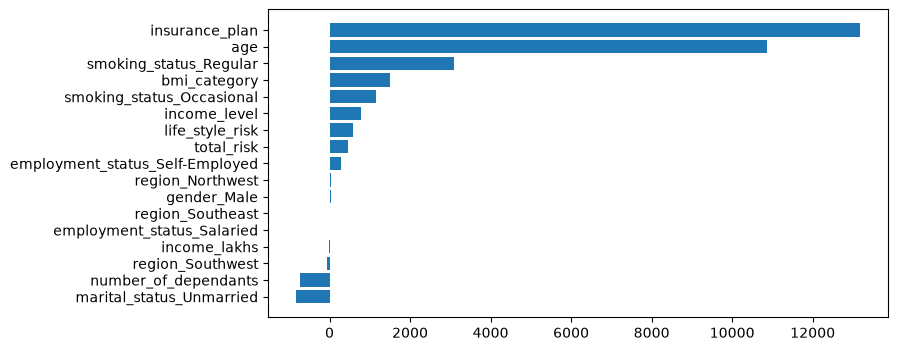

In [288]:
feature_importance=linear_model.coef_
coef_df=pd.DataFrame(feature_importance,index=X_train.columns,columns=['coefficients'])
coef_df=coef_df.sort_values(by='coefficients',ascending=True)

plt.figure(figsize=(8,4))
plt.barh(coef_df.index,coef_df['coefficients'])
plt.show()

In [289]:
xgboot=XGBRegressor()
params_grid = {
    'n_estimators':[20,40,50],
    'learning_rate':[0.01,0.1,0.2],
    'max_depth':[3,4,5]
}

random_search=RandomizedSearchCV(xgboot,params_grid,n_iter=10,cv=3,scoring='r2',random_state=42)
random_search.fit(X_train,y_train)
print(random_search.best_score_)
best_model=random_search.best_estimator_

0.9926497936248779


In [290]:
feature_importance=best_model.feature_importances_
feature_importance

array([5.1469177e-01, 9.4622155e-05, 1.9790852e-02, 2.2449606e-04,
       1.6099475e-04, 4.0697977e-01, 2.1394297e-02, 1.0992376e-02,
       4.7695055e-04, 2.1442008e-04, 1.3119458e-04, 1.9691524e-04,
       2.7059138e-04, 4.8692380e-03, 1.9370152e-02, 9.5196228e-05,
       4.6197660e-05], dtype=float32)

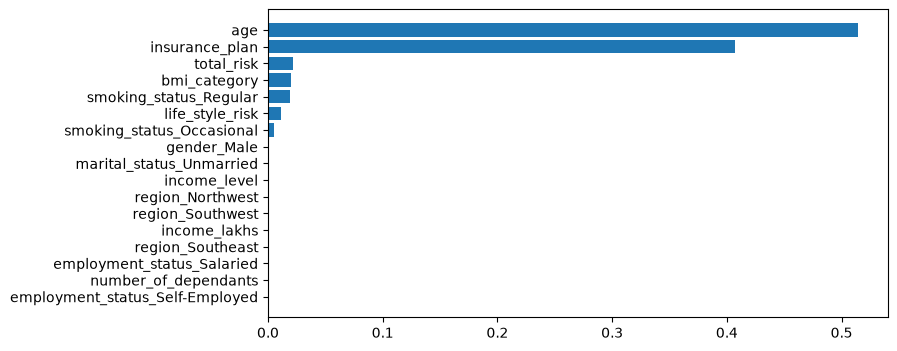

In [291]:
coef_df=pd.DataFrame(feature_importance,index=X_train.columns,columns=['coefficients'])
coef_df=coef_df.sort_values(by='coefficients',ascending=True)

plt.figure(figsize=(8,4))
plt.barh(coef_df.index,coef_df['coefficients'])
plt.show()

In [292]:
y_pred=best_model.predict(X_test)
residual=((y_pred-y_test)/y_test)*100
residual

2139    10.225911
9100    20.599447
6755    -4.033794
7661    -6.344643
8226    -1.161344
          ...    
3208    -3.789441
810      2.454216
6210     1.877607
6179     0.758743
6669     4.759410
Name: annual_premium_amount, Length: 2931, dtype: float64

<Axes: xlabel='annual_premium_amount', ylabel='Count'>

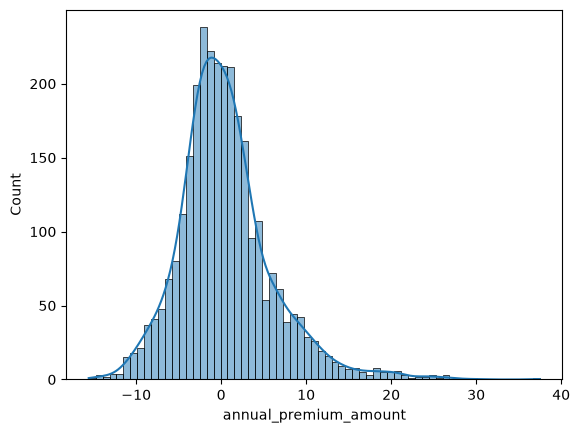

In [293]:
sns.histplot(residual,kde=True)

In [296]:
from joblib import dump

dump(best_model,"../artifacts/model_rest.joblib")
scaler_with_cols = {
    'scaler':scaler,
    'cols_to_scale':cols_to_scale
}

dump(scaler_with_cols,"../artifacts/scaler_rest.joblib")

['../artifacts/scaler_rest.joblib']